# Project Understanding

This project we will classify sentiments of comments in google play store for dana application. Dana is one of digital wallet in indonesia that it can be used for save money, transfer, and pay bill of services. The data that we will be used in this project was scrapped from google playstore and  contain 10000 comments. These comment will be classify into 3 classes such as positive, neutral, and negative.

# Import Libraries

In [1]:
from google_play_scraper import Sort, reviews
from google_play_scraper import app

import csv
import requests
from io import StringIO

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import re
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory


from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Flatten

from tensorflow.keras.regularizers import l2

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

# Load Dataset

In [ ]:
result, continuation_token = reviews(
    'id.dana',
    lang='id',
    country='id',
    sort=Sort.MOST_RELEVANT,
    count=10000,
    filter_score_with=None
)

In [ ]:
reviews = pd.DataFrame(np.array(result), columns=['review'])
reviews = reviews.join(reviews.DataFrame(reviews.pop('review').tolist()))

In [3]:
reviews.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,067a0499-b344-4be3-a1e3-199d490d84aa,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Mulai sekarang mending pindah ke aplikasi lain...,1,41,2.113.1,2026-02-10 07:47:24,"Hi Kak, mohon maaf atas pengalaman buruknya. K...",2026-02-10 09:51:55,2.113.1
1,ee5d5b79-6773-4280-88c7-a3770acdf184,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,kasih 3 bintang aja ya 🙏🏻 😁.. lumayan juga bua...,3,26,2.113.1,2026-02-07 22:07:36,"Hi Kak Ibnu, Kami memahami ketidaknyamanan yg ...",2026-02-07 22:47:48,2.113.1
2,586f7802-93c5-4d1e-95a4-f966cc648f60,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Aduh DANA. Tolong dong. Ada apa ini dengan sis...,4,308,2.112.0,2026-01-31 16:49:13,NaN,NaN,2.112.0
3,733fc798-77dc-45e3-8866-8026103979d8,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Aplikasi nya Sangat Bangus Untuk Transaksi dan...,3,393,2.111.0,2026-01-19 23:49:10,NaN,NaN,2.111.0
4,78b79ed7-714a-4530-9ae5-289d5afbd7a0,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"awalnya bagus, pas d upgrade juha gampang ga k...",3,2,2.113.1,2026-02-09 11:42:19,"Hi Kak, mohon maaf atas kendala scan barcode y...",2026-02-09 14:13:13,2.113.1


In [4]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              10000 non-null  object
 1   userName              10000 non-null  object
 2   userImage             10000 non-null  object
 3   content               10000 non-null  object
 4   score                 10000 non-null  int64 
 5   thumbsUpCount         10000 non-null  int64 
 6   reviewCreatedVersion  9999 non-null   object
 7   at                    10000 non-null  object
 8   replyContent          7643 non-null   object
 9   repliedAt             7643 non-null   object
 10  appVersion            9999 non-null   object
dtypes: int64(2), object(9)
memory usage: 859.5+ KB


In [5]:
clean_df = reviews.drop(columns=['replyContent', 'repliedAt'])

# Preprocessing Text

There are several functions that we will use for this project for cleaning data in this dataset. such as :

1. cleaningText(text)
- Removes mentions (@username), hashtags, retweets (RT), links, numbers, and non-alphanumeric characters.
- Replaces newlines with spaces, strips punctuation, and trims whitespace.
- Purpose: Produces a clean, uniform text string free of noise.

2. casefoldingText(text)
- Converts all characters to lowercase.
- Purpose: Ensures consistency (e.g., “Good” and “good” are treated the same).

3. tokenizingText(text)
- Splits text into individual tokens (words).
- Purpose: Prepares text for word-level processing like stopword removal.

4. filteringText(text)
- Removes stopwords in both Indonesian and English.
- Adds custom stopwords (like “iya”, “yaa”, “gak”, etc.) to handle informal language.
- Purpose: Keeps only meaningful words that contribute to sentiment or context.

5. stemmingText(text)
- Uses the Sastrawi stemmer (Indonesian) to reduce words to their root form.
- Example: “berlari” → “lari”.
- Purpose: Normalizes words so variations are treated as the same.

6. toSentence(list_words)
- Joins a list of words back into a sentence.
- Purpose: Converts processed tokens into a readable string.

In [6]:
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text) # menghapus mention
    text = re.sub(r'#[A-Za-z0-9]+', '', text) # menghapus hashtag
    text = re.sub(r'RT[\s]', '', text) # menghapus RT
    text = re.sub(r"http\S+", '', text) # menghapus link
    text = re.sub(r'[0-9]+', '', text) # menghapus angka
    text = re.sub(r'[^\w\s]', '', text) # menghapus karakter selain huruf dan angka
 
    text = text.replace('\n', ' ') # mengganti baris baru dengan spasi
    text = text.translate(str.maketrans('', '', string.punctuation)) # menghapus semua tanda baca
    text = text.strip(' ') # menghapus karakter spasi dari kiri dan kanan teks
    return text
 
def casefoldingText(text): # Mengubah semua karakter dalam teks menjadi huruf kecil
    text = text.lower()
    return text
 
def tokenizingText(text): # Memecah atau membagi string, teks menjadi daftar token
    text = word_tokenize(text)
    return text
 
def filteringText(text): # Menghapus stopwords dalam teks
    listStopwords = set(stopwords.words('indonesian'))
    listStopwords1 = set(stopwords.words('english'))
    listStopwords.update(listStopwords1)
    listStopwords.update(['iya','yaa','gak','nya','na','sih','ku',"di","ga","ya","gaa","loh","kah","woi","woii","woy"])
    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text
 
def stemmingText(text): # Mengurangi kata ke bentuk dasarnya yang menghilangkan imbuhan awalan dan akhiran atau ke akar kata
    # Membuat objek stemmer
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()
 
    # Memecah teks menjadi daftar kata
    words = text.split()
 
    # Menerapkan stemming pada setiap kata dalam daftar
    stemmed_words = [stemmer.stem(word) for word in words]
 
    # Menggabungkan kata-kata yang telah distem
    stemmed_text = ' '.join(stemmed_words)
 
    return stemmed_text
 
def toSentence(list_words): # Mengubah daftar kata menjadi kalimat
    sentence = ' '.join(word for word in list_words)
    return sentence

slangwords = {"@": "di", "abis": "habis", "wtb": "beli", "masi": "masih", "wts": "jual", "wtt": "tukar", "bgt": "banget", "maks": "maksimal"}
def fix_slangwords(text):
    words = text.split()
    fixed_words = []
 
    for word in words:
        if word.lower() in slangwords:
            fixed_words.append(slangwords[word.lower()])
        else:
            fixed_words.append(word)
 
    fixed_text = ' '.join(fixed_words)
    return fixed_text

In [8]:
# Membersihkan teks dan menyimpannya di kolom 'text_clean'
clean_df['text_clean'] = clean_df['content'].apply(cleaningText)
 
# Mengubah huruf dalam teks menjadi huruf kecil dan menyimpannya di 'text_casefoldingText'
clean_df['text_casefoldingText'] = clean_df['text_clean'].apply(casefoldingText)
 
# Mengganti kata-kata slang dengan kata-kata standar dan menyimpannya di 'text_slangwords'
clean_df['text_slangwords'] = clean_df['text_casefoldingText'].apply(fix_slangwords)
 
# Memecah teks menjadi token (kata-kata) dan menyimpannya di 'text_tokenizingText'
clean_df['text_tokenizingText'] = clean_df['text_slangwords'].apply(tokenizingText)
 
# Menghapus kata-kata stop (kata-kata umum) dan menyimpannya di 'text_stopword'
clean_df['text_stopword'] = clean_df['text_tokenizingText'].apply(filteringText)
 
# Menggabungkan token-token menjadi kalimat dan menyimpannya di 'text_akhir'
clean_df['text_akhir'] = clean_df['text_stopword'].apply(toSentence)

# Labeling

In [9]:
# Membaca data kamus kata-kata positif dari GitHub
lexicon_positive = dict()
 
response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub
 
if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma
 
    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_positive[row[0]] = int(row[1])
        # Menambahkan kata-kata positif dan skornya ke dalam kamus lexicon_positive
else:
    print("Failed to fetch positive lexicon data")
 
# Membaca data kamus kata-kata negatif dari GitHub
lexicon_negative = dict()
 
response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub
 
if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma
 
    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_negative[row[0]] = int(row[1])
        # Menambahkan kata-kata negatif dan skornya dalam kamus lexicon_negative
else:
    print("Failed to fetch negative lexicon data")

In [10]:
# Fungsi untuk menentukan polaritas sentimen dari tweet
 
def sentiment_analysis_lexicon_indonesia(text):
    #for word in text:
 
    score = 0
    # Inisialisasi skor sentimen ke 0
 
    for word in text:
        # Mengulangi setiap kata dalam teks
 
        if (word in lexicon_positive):
            score = score + lexicon_positive[word]
            # Jika kata ada dalam kamus positif, tambahkan skornya ke skor sentimen
 
    for word in text:
        # Mengulangi setiap kata dalam teks (sekali lagi)
 
        if (word in lexicon_negative):
            score = score + lexicon_negative[word]
            # Jika kata ada dalam kamus negatif, kurangkan skornya dari skor sentimen
 
    polarity=''
    # Inisialisasi variabel polaritas
 

    if (score >= 0):
        polarity = 'positive'
    elif (score <= -7):
        polarity = 'negative'
    else:
        polarity = 'neutral'
 
    return score, polarity
    # Mengembalikan skor sentimen dan polaritas teks 
    

In [11]:
results = clean_df['text_stopword'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))
clean_df['polarity_score'] = results[0]
clean_df['polarity'] = results[1]
print(clean_df['polarity'].value_counts())

polarity
positive    5816
neutral     2397
negative    1787
Name: count, dtype: int64


<Axes: xlabel='polarity', ylabel='count'>

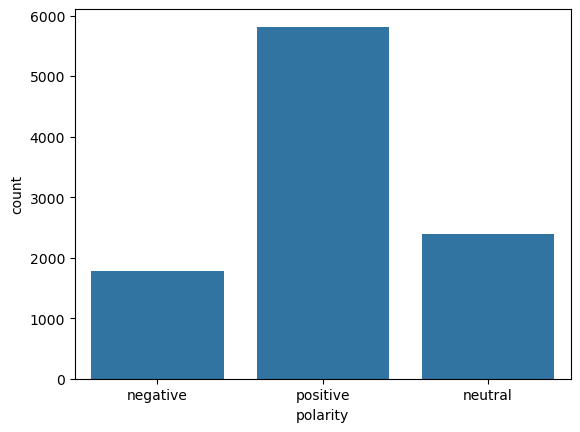

In [13]:
sns.countplot(data=clean_df,x='polarity') 

# Tokenizing & Train Test Split

In [15]:
# Pisahkan data menjadi fitur (tweet) dan label (sentimen)
X = clean_df[['text_akhir']]
y = clean_df[['polarity']]

In [16]:
tokenizer = Tokenizer(num_words=100000, oov_token="<OOV>", split=' ')
tokenizer.fit_on_texts(X['text_akhir'].values)

X_sequences = tokenizer.texts_to_sequences(X['text_akhir'].values)

word_index = tokenizer.word_index
vocab_size    = min(100000, len(word_index)) + 1

In [17]:
maxlen = 200

X_sequences =  pad_sequences(X_sequences, maxlen=maxlen, padding='post')

In [18]:
word_index = tokenizer.word_index
vocab_size = min(100000, len(word_index)) + 1

In [21]:
enc = OrdinalEncoder(categories=[['negative','neutral','positive']])
y = enc.fit_transform(y)

In [22]:
X_train_padded, X_test_padded, y_train, y_test = train_test_split(X_sequences, y, test_size=0.2, random_state=42)

# Modelling

For this project we will use lstm model, because lstm can handle and understand text and it's popular for sentiment analysis problem. 

In [30]:
reg_l2 = l2(0.0001) 

In [32]:
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=32, input_length=maxlen, embeddings_regularizer=reg_l2),
    LSTM(32, return_sequences=True),
    LSTM(64, return_sequences=True),
    Dropout(0.5),
    Flatten(),
    Dropout(0.5),
    Dense(30, activation = 'relu'),
    Dense(10, activation = 'relu'),
    Dense(3, activation='softmax'),
])

C:\Users\GF63\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1. Embedding Layer
- Converts word indices into dense 32-dimensional vectors.
- Learns semantic representations of words during training.
- embeddings_regularizer=reg_l2 applies L2 regularization to prevent overfitting by penalizing large weights.
- Input length = maxlen ensures all sequences are padded/truncated to the same size.

2. First LSTM Layer
- Processes the sequence of word embeddings.
- 32 memory units capture temporal dependencies (context across words).
- return_sequences=True outputs the full sequence, allowing stacking of another LSTM.

3. Second LSTM Layer
- Deeper recurrent layer with 64 units.
- Learns more complex sequential patterns (e.g., sentiment phrases, negations).
- Again returns sequences for further processing.

4. Dropout Layer
- Randomly drops 50% of neurons during training.
- Prevents overfitting by forcing the network to generalize.

5. Flatten Layer
- Converts the 3D sequence output into a 1D vector.
- Prepares data for fully connected layers.

6. Second Dropout Layer
- Adds another regularization step before dense layers.

7. Dense Layers
- Fully connected layers with ReLU activation.
- Learn non-linear combinations of features extracted by LSTMs.
- Provide hierarchical feature abstraction.

8. Output layer
- Final classification layer with 3 neurons.
- Each neuron corresponds to a sentiment class (e.g., positive, negative, neutral).
- Softmax ensures outputs are probabilities that sum to 1.

9. Optimizer
- Adam, is computationally efficient gradient descent algorithm that computes individual, adaptive learning rates for different parameters by combining the advantages of Momentum and RMSprop.

10. Loss Function
- The loss function sparse_categorical_crossentropy is used in multi-class classification problems

In [33]:
class MyCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs={}):
      if(logs.get('accuracy') > 0.84 and logs.get('val_accuracy') > 0.84):
          print("\nReach 84% accuracy so cancelling training!")
          self.model.stop_training = True

callbacks = MyCallback()

In [34]:
# Compile model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [35]:
history = model.fit(X_train_padded, y_train, epochs = 100, callbacks = ([callbacks]), validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 20s 84ms/step - accuracy: 0.6759 - loss: 0.7385 - val_accuracy: 0.7981 - val_loss: 0.4874
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 16s 82ms/step - accuracy: 0.8545 - loss: 0.3599 - val_accuracy: 0.8325 - val_loss: 0.4568
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 16s 82ms/step - accuracy: 0.9237 - loss: 0.2082 - val_accuracy: 0.8381 - val_loss: 0.4580
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 16s 82ms/step - accuracy: 0.9489 - loss: 0.1481 - val_accuracy: 0.8194 - val_loss: 0.5801
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 16s 82ms/step - accuracy: 0.9605 - loss: 0.1192 - val_accuracy: 0.8275 - val_loss: 0.5973
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 16s 82ms/step - accuracy: 0.9686 - loss: 0.1009 - val_accuracy: 0.8269 - val_loss: 0.6622
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.9773 - loss: 0.0841
Reach 84% accuracy so cancelling training!
200/200 ━━━━━━━━━━━━━━━━━━━━ 21s 84ms/step - accuracy: 0.9762 - loss: 0.0889 - val_

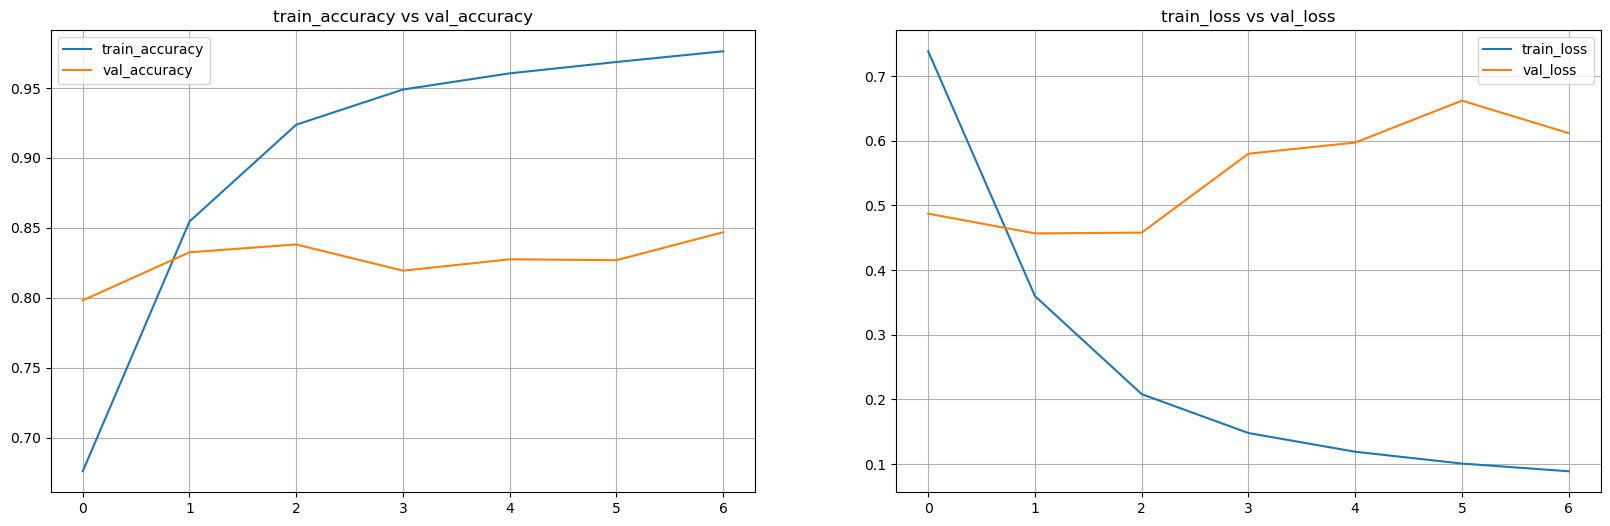

In [36]:
fig, axes = plt.subplots(1,2, figsize=[20,6])
sns.lineplot(data=history.history['accuracy'], ax=axes[0], label='train_accuracy')
sns.lineplot(data=history.history['val_accuracy'], ax=axes[0], label='val_accuracy')
axes[0].set_title('train_accuracy vs val_accuracy')


sns.lineplot(data=history.history['loss'], ax=axes[1], label='train_loss')
sns.lineplot(data=history.history['val_loss'], ax=axes[1], label='val_loss')
axes[1].set_title('train_loss vs val_loss')


axes[0].grid(True)
axes[1].grid(True)
plt.show() 

In [38]:
pred_probabilities = model.predict(X_test_padded)

y_pred = np.argmax(pred_probabilities, axis=1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step


In [40]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.89      0.76      0.82       365
         1.0       0.65      0.78      0.71       464
         2.0       0.94      0.91      0.92      1171

    accuracy                           0.85      2000
   macro avg       0.83      0.82      0.82      2000
weighted avg       0.86      0.85      0.85      2000



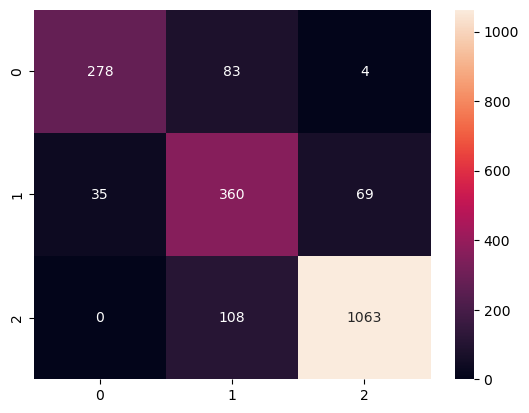

In [42]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.show()

In [45]:
model.save('model_LSTM.h5')